# Анализ строительной отрасли России

## 1. Подключение библиотек

## 2. Получение данных

## 3. Очистка данных

## 4. Исследовательский анализ

## 5. Выводы

## 1. Подключение библиотек

In [51]:
import requests
import random
%pip install matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Получение данных
### 2.1 Получение списка компаний

In [2]:
url = "https://bo.nalog.gov.ru/advanced-search/organizations"

headers = {
    "User-Agent": "Mozilla/5.0"
}

params = {
    "allFieldsMatch": True,
    "okved": "41.20",
    "page": 499,
    "size": 20
}

response = requests.get(
    url,
    params=params,
    headers=headers
)

print(response.status_code)

200


### 2.2 Исследование структуры API

In [3]:
print(response.url)

https://bo.nalog.gov.ru/advanced-search/organizations?allFieldsMatch=True&okved=41.20&page=499&size=20


In [4]:
print(response.text[:1000])

{"content":[{"id":11928661,"inn":"2368016940","shortName":"ООО \"СТРОЙДОМ\"","ogrn":"1222300044966","index":"352690","region":"КРАСНОДАРСКИЙ","district":"Апшеронский","city":"Апшеронск","settlement":null,"street":"РАБОЧАЯ","house":"38А","building":null,"office":null,"okved2":"<strong>41.20</strong>","okopf":12300,"okato":null,"okpo":null,"okfs":null,"statusCode":"INACTIVE","statusDate":"2026-02-13","bfo":{"period":"2024","actualBfoDate":"2025-03-25","gainSum":0,"knd":"0710096","hasAz":false,"hasKs":false,"actualCorrectionNumber":0,"actualCorrectionDate":"2025-03-25","isCb":false,"bfoPeriodTypes":[12]}},{"id":11365512,"inn":"5035031880","shortName":"ООО \"А-СТРОЙ\"","ogrn":"1205000063058","index":"121596","region":"МОСКВА","district":null,"city":null,"settlement":null,"street":"ГОРБУНОВА","house":"2","building":"3","office":"II","okved2":"<strong>41.20</strong>","okopf":12300,"okato":null,"okpo":null,"okfs":null,"statusCode":"ACTIVE","statusDate":"2026-02-13","bfo":{"period":"2022","act

In [5]:
search_data = response.json()

In [6]:
companies = search_data["content"]
len(companies)
print(f"Всего компаний: {search_data['totalElements']}")
print(f"Всего страниц: {search_data['totalPages']}")

Всего компаний: 174655
Всего страниц: 8733


По запросу по критериям: вид деятельности "41.20" -- API ФНС возвращает 174651 компаний, распределенных по 8733 страницам, для исследования будет рассматриваться случайная выборка из 100 страниц. Методом тыка выяснил, что после 500 страницы есть ограничение API, поэтому выборку буду делать из первых 500 страниц, это можно расценивать как незначительное смещение.

In [7]:
keys = companies[0]["bfo"].keys()
for i in keys:
    print(companies[0]["bfo"][i])

2024
2025-03-25
0
0710096
False
False
0
2025-03-25
False
[12]


In [8]:
print(type(search_data))
print(type(search_data["content"]))
print(type(search_data["content"][0]))

<class 'dict'>
<class 'list'>
<class 'dict'>


In [9]:
print(search_data.keys())

dict_keys(['content', 'pageable', 'totalPages', 'totalElements', 'last', 'first', 'numberOfElements', 'size', 'number', 'sort', 'empty'])


In [10]:
print(len(search_data["content"]))

20


In [11]:
print(search_data["content"][0])

{'id': 11928661, 'inn': '2368016940', 'shortName': 'ООО "СТРОЙДОМ"', 'ogrn': '1222300044966', 'index': '352690', 'region': 'КРАСНОДАРСКИЙ', 'district': 'Апшеронский', 'city': 'Апшеронск', 'settlement': None, 'street': 'РАБОЧАЯ', 'house': '38А', 'building': None, 'office': None, 'okved2': '<strong>41.20</strong>', 'okopf': 12300, 'okato': None, 'okpo': None, 'okfs': None, 'statusCode': 'INACTIVE', 'statusDate': '2026-02-13', 'bfo': {'period': '2024', 'actualBfoDate': '2025-03-25', 'gainSum': 0, 'knd': '0710096', 'hasAz': False, 'hasKs': False, 'actualCorrectionNumber': 0, 'actualCorrectionDate': '2025-03-25', 'isCb': False, 'bfoPeriodTypes': [12]}}


In [12]:
print(search_data["content"][0].keys())

dict_keys(['id', 'inn', 'shortName', 'ogrn', 'index', 'region', 'district', 'city', 'settlement', 'street', 'house', 'building', 'office', 'okved2', 'okopf', 'okato', 'okpo', 'okfs', 'statusCode', 'statusDate', 'bfo'])


### 2.3 Получение финансовой отчетности

In [13]:
url = "https://bo.nalog.gov.ru/nbo/organizations/11107880/bfo/"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(
    url,
    headers=headers
)

print(response.status_code)
print(response.text[:1000])

200
[{"id":13059894,"period":"2021","publication":200006,"actualBfoDate":"2022-02-17","gainSum":36583,"knd":"0710096","hasAz":false,"hasKs":null,"actualCorrectionNumber":0,"actualCorrectionDate":"2022-02-17","publishedCorrectionNumber":0,"publishedCorrectionDate":"2022-04-11","actives":14144.0,"isCb":false,"mspCategory":null,"organizationInfo":{"fullName":"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ МНОГОПРОФИЛЬНАЯ СТРОИТЕЛЬНАЯ КОМПАНИЯ \"СИБМОНТАЖ\"","inn":"5404093218","kpp":"540401001","address":"630052, г. Новосибирск, Толмачевское ш., д. 43, кв. 5","okved2_id":"41.20","okved2":{"id":"41.20","name":"Строительство жилых и нежилых зданий"},"okopf_id":12300,"okopf":{"id":12300,"name":"Общества с ограниченной ответственностью"},"okfs_id":16,"okfs":{"id":16,"name":"Частная собственность"},"okpo":"41180876"},"typeCorrections":[{"type":12,"correction":{"id":40702408,"bfoOrganizationInfo":{"id":40702408,"fullName":"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ МНОГОПРОФИЛЬНАЯ СТРОИТЕЛЬНАЯ КОМПАНИЯ 

### 2.4 Исследование структуры второго API

In [14]:
financial_data = response.json()
for report in financial_data:
    print(report["period"])

2021


In [15]:
print(financial_data[0]["typeCorrections"])

[{'type': 12, 'correction': {'id': 40702408, 'bfoOrganizationInfo': {'id': 40702408, 'fullName': 'ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ МНОГОПРОФИЛЬНАЯ СТРОИТЕЛЬНАЯ КОМПАНИЯ "СИБМОНТАЖ"', 'inn': '5404093218', 'kpp': '540401001', 'address': '630052, г. Новосибирск, Толмачевское ш., д. 43, кв. 5', 'okved2': {'id': '41.20', 'name': 'Строительство жилых и нежилых зданий'}, 'okopf_id': 12300, 'okopf': {'id': 12300, 'name': 'Общества с ограниченной ответственностью'}, 'okfs_id': 16, 'okfs': {'id': 16, 'name': 'Частная собственность'}, 'bfoId': 13059894, 'okpo': '41180876'}, 'balance': {'id': 40702408, 'okud': '0710001', 'expl1105': None, 'current1105': None, 'previous1105': None, 'beforePrevious1105': None, 'expl1110': None, 'current1110': None, 'previous1110': None, 'beforePrevious1110': None, 'expl1120': None, 'current1120': None, 'previous1120': None, 'beforePrevious1120': None, 'expl1130': None, 'current1130': None, 'previous1130': None, 'beforePrevious1130': None, 'expl1140': None, '

In [16]:
financial_data[0]["typeCorrections"][0]["correction"]["bfoOrganizationInfo"]["fullName"]

'ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ МНОГОПРОФИЛЬНАЯ СТРОИТЕЛЬНАЯ КОМПАНИЯ "СИБМОНТАЖ"'

In [17]:
financial_data[0]["typeCorrections"][0]["correction"]["bfoOrganizationInfo"]["inn"]

'5404093218'

In [18]:
financial_data[0]["typeCorrections"][0]["correction"]["financialResult"]["current2110"]

36583.0

### 2.5. Подсчет EBIT

In [19]:
results = []
headers = {
    "User-Agent": "Mozilla/5.0"
    }

for company in companies:
    url = f"https://bo.nalog.gov.ru/nbo/organizations/{company['id']}/bfo/"
    
    response = requests.get(
    url,
    headers=headers
    )
    
    financial_data = response.json()
    
    if not financial_data:
        continue
    report = financial_data[0]
    correction = report["typeCorrections"][0]["correction"]
    financial_result = correction["financialResult"]
    
    interest = financial_result.get("current2330", 0)
    net_profit = financial_result.get("current2400", 0)
    income_tax = financial_result.get("current2410", 0)
    EBIT = (
    net_profit + 
    income_tax + 
    interest
    )
    
    company_info = {
    "id": company["id"],
    "name": company["shortName"],
    "inn": company["inn"],
    "region": company["region"],
    "period": int(report["period"]),
    "revenue": financial_result.get("current2110", 0),
    "net_profit": net_profit,
    "ebit": EBIT
    }
    
    results.append(company_info)
print(results[0])

{'id': 11928661, 'name': 'ООО "СТРОЙДОМ"', 'inn': '2368016940', 'region': 'КРАСНОДАРСКИЙ', 'period': '2024', 'revenue': 0.0, 'net_profit': 0.0, 'ebit': 0.0}


Научились считать EBIT на списке из 20 компаний, дальше соберем случайную выборку

### 2.6 Делаем случайную выборку

In [20]:
all_companies = []
url = "https://bo.nalog.gov.ru/advanced-search/organizations"
headers = {
    "User-Agent": "Mozilla/5.0"
    }

for i in random.sample(range(500),100):

    params = {
    "allFieldsMatch": True,
    "okved": "41.20",
    "page": i,
    "size": 20
    }

    try:
        response = requests.get(
        url,
        params=params,
        headers=headers
        )
        response.raise_for_status()
    except:
        print(f"страницы {i} не существует, или она вызывает проблему")
        continue
        
    data = response.json()
    all_companies.extend(data["content"])
print(len(all_companies))
print(type(all_companies[0]))

2000
<class 'dict'>


Сделали случайную выборку из 2000 компаний

### 2.7 Собираем датасет и делаем DataFrame

In [33]:
results = []
headers = {
    "User-Agent": "Mozilla/5.0"
    }

for company in all_companies:
    url = f"https://bo.nalog.gov.ru/nbo/organizations/{company['id']}/bfo/"

    try:
        response = requests.get(
            url,
            headers=headers,
            timeout=10
        )
        response.raise_for_status()
    except requests.exceptions.RequestException:
        continue

    financial_data = response.json()

    if not financial_data:
        continue

    for report in financial_data:

        if not report["typeCorrections"]:
            continue
        
        correction = report["typeCorrections"][0]["correction"]
        if "financialResult" not in correction:
            continue
        financial_result = correction["financialResult"]
    
        interest = financial_result.get("current2330", 0)
        net_profit = financial_result.get("current2400", 0)
        income_tax = financial_result.get("current2410", 0)
    
        EBIT = (
        net_profit + 
        income_tax + 
        interest
        )
    
        company_info = {
        "id": company["id"],
        "name": company["shortName"],
        "inn": company["inn"],
        "region": company["region"],
        "period": int(report["period"]),
        "revenue": financial_result.get("current2110", 0),
        "net_profit": net_profit,
        "ebit": EBIT
        }
    
        results.append(company_info)
    
print(len(results))
print(results[0])
df = pd.DataFrame(results)

df.groupby("id").size().describe()

4136
{'id': 10848301, 'name': 'ООО "СТС"', 'inn': '8603235783', 'region': 'ХАНТЫ-МАНСИЙСКИЙ АВТОНОМНЫЙ ОКРУГ - ЮГРА', 'period': 2024, 'revenue': 0, 'net_profit': 0, 'ebit': 0}


count    1944.000000
mean        2.127572
std         1.226815
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        10.000000
dtype: float64

In [34]:
df = pd.DataFrame(results)

df.head()

df.info()

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4136 entries, 0 to 4135
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          4136 non-null   int64  
 1   name        4136 non-null   str    
 2   inn         4136 non-null   str    
 3   region      4136 non-null   str    
 4   period      4136 non-null   int64  
 5   revenue     4136 non-null   float64
 6   net_profit  4136 non-null   float64
 7   ebit        4136 non-null   float64
dtypes: float64(3), int64(2), str(3)
memory usage: 258.6 KB


,id,period,revenue,net_profit,ebit
count,4.136000e+03,4136.000000,4.136000e+03,4.136000e+03,4.136000e+03
mean,9.357509e+06,2022.182060,3.479892e+04,7.671528e+02,8.953320e+02
std,3.124460e+06,1.113825,1.593202e+05,6.981052e+04,6.982851e+04
min,5.273900e+04,2021.000000,0.000000e+00,-1.610068e+06,-1.610068e+06
25%,8.492196e+06,2021.000000,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.064048e+07,2022.000000,2.185000e+02,0.000000e+00,0.000000e+00
75%,1.153630e+07,2023.000000,1.164050e+04,1.030000e+02,1.210000e+02
max,1.260615e+07,2025.000000,3.946112e+06,3.011437e+06,3.008874e+06


In [35]:
df.to_csv("construction_companies.csv", index=False)

## 3. Очистка данных

In [4]:
df = pd.read_csv("construction_data_clean.csv")

In [5]:
df = df[df["period"] < 2025]

В 2025 году всего 49 записей, поэтому исключаем его для того, чтобы избежать выбросов

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isna().sum()

id            0
name          0
inn           0
region        0
period        0
revenue       0
net_profit    0
ebit          0
dtype: int64

In [8]:
df.describe(include="all")

,id,name,inn,region,period,revenue,net_profit,ebit
count,3.998000e+03,3998,3.998000e+03,3998,3998.000000,3.998000e+03,3.998000e+03,3.998000e+03
unique,NaN,1779,NaN,83,NaN,NaN,NaN,NaN
top,NaN,"ООО ""АЛЬЯНС""",NaN,МОСКВА,NaN,NaN,NaN,NaN
freq,NaN,13,NaN,891,NaN,NaN,NaN,NaN
mean,9.335014e+06,NaN,5.463378e+09,NaN,2022.143322,3.491252e+04,8.027166e+02,9.213762e+02
std,3.129719e+06,NaN,2.764208e+09,NaN,1.074283,1.605762e+05,7.098664e+04,7.100216e+04
min,5.273900e+04,NaN,1.050816e+08,NaN,2021.000000,0.000000e+00,-1.610068e+06,-1.610068e+06
25%,8.475315e+06,NaN,2.724234e+09,NaN,2021.000000,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.055859e+07,NaN,5.836687e+09,NaN,2022.000000,2.275000e+02,0.000000e+00,0.000000e+00
75%,1.153029e+07,NaN,7.725782e+09,NaN,2023.000000,1.168025e+04,1.047500e+02,1.227500e+02


In [9]:
df[df.duplicated(keep=False)].sort_values(["id", "period"])

,id,name,inn,region,period,revenue,net_profit,ebit


In [10]:
df = df.drop_duplicates()

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
print(df.shape)

(3998, 8)


In [13]:
df.to_csv("construction_data_clean.csv", index=False)

## 4. Исследовательский анализ

### 4.1 Описание выборки

In [14]:
summary = pd.DataFrame({
    "Показатель": [
        "Количество компаний",
        "Количество наблюдений",
        "Период исследования",
        "Количество регионов",
        "Доля компаний с нулевой выручкой",
        "Доля компаний с нулевой прибылью"
    ],
    "Значение": [
        df["id"].nunique(),
        len(df),
        f"{df['period'].min()}–{df['period'].max()}",
        df["region"].nunique(),
        f"{(df['revenue'] == 0).mean():.1%}",
        f"{(df['net_profit'] == 0).mean():.1%}"
    ]
})

display(summary)

,Показатель,Значение
0,Количество компаний,1944
1,Количество наблюдений,3998
2,Период исследования,2021–2024
3,Количество регионов,83
4,Доля компаний с нулевой выручкой,47.0%
5,Доля компаний с нулевой прибылью,37.8%


In [15]:
summary.to_csv("summary.csv", index=False)

###  Анализ распределения компаний по регионам

In [16]:
region_counts = (
    df.groupby("region")["id"]
      .nunique()
      .sort_values(ascending=False)
)

region_counts.head(15)

region
МОСКВА             492
САНКТ-ПЕТЕРБУРГ    127
МОСКОВСКАЯ         103
КРАСНОДАРСКИЙ       75
БАШКОРТОСТАН        72
ТАТАРСТАН           66
НОВОСИБИРСКАЯ       58
СВЕРДЛОВСКАЯ        49
САМАРСКАЯ           42
ПРИМОРСКИЙ          39
НИЖЕГОРОДСКАЯ       34
ЧЕЛЯБИНСКАЯ         30
ТЮМЕНСКАЯ           29
КРАСНОЯРСКИЙ        27
КРЫМ                27
Name: id, dtype: int64

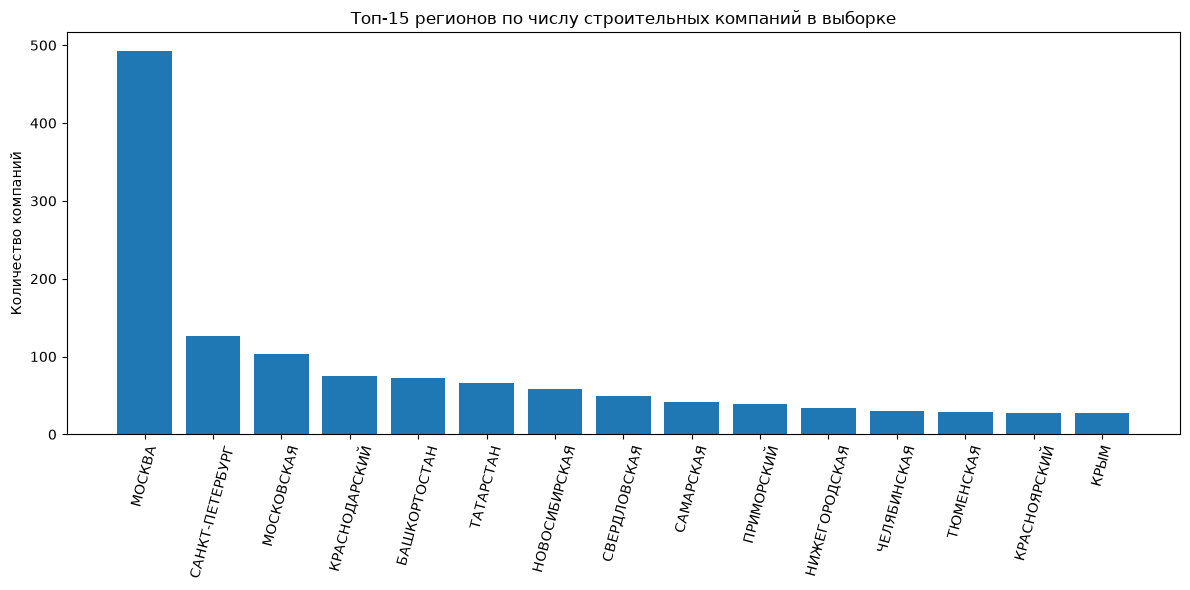

In [17]:
top15 = region_counts.head(15)

plt.figure(figsize=(12, 6))
plt.bar(top15.index, top15.values)

plt.xticks(rotation=75)
plt.ylabel("Количество компаний")
plt.title("Топ-15 регионов по числу строительных компаний в выборке")

plt.tight_layout()
plt.show()

Выборка распределена по регионам неравномерно. На Москву приходится 492 компании (около 27,7% всей выборки), что значительно превышает показатели остальных регионов. Второе место занимает Санкт-Петербург (127 компаний), третье — Московская область (103 компании). Это свидетельствует о высокой концентрации строительных организаций в крупнейших экономических центрах страны.

### 4.2 Анализ финансовых показателей

In [18]:
df[["revenue", "net_profit", "ebit"]].describe(
    percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]
)

,revenue,net_profit,ebit
count,3.998000e+03,3.998000e+03,3.998000e+03
mean,3.491252e+04,8.027166e+02,9.213762e+02
std,1.605762e+05,7.098664e+04,7.100216e+04
min,0.000000e+00,-1.610068e+06,-1.610068e+06
1%,0.000000e+00,-2.086862e+04,-1.870990e+04
5%,0.000000e+00,-1.588850e+03,-1.462000e+03
25%,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.275000e+02,0.000000e+00,0.000000e+00
75%,1.168025e+04,1.047500e+02,1.227500e+02
95%,1.616877e+05,3.222900e+03,3.778750e+03


In [19]:
(df["revenue"] == 0).sum()

np.int64(1880)

In [20]:
(df["revenue"] == 0).mean()

np.float64(0.4702351175587794)

### Анализ описательной статистики
Полученная выборка характеризуется высокой неоднородностью финансовых показателей. Среднее значение выручки существенно превышает медианное (34 913 против 227,5 тыс. рублей), что свидетельствует о сильной правосторонней асимметрии распределения. Аналогичная ситуация наблюдается для чистой прибыли и EBIT.

Кроме того, значительная часть наблюдений имеет нулевые значения финансовых показателей, что может быть связано с отсутствием хозяйственной деятельности, недавно созданными организациями либо нулевой отчётностью.

Для дальнейшего анализа распределений целесообразно использовать логарифмическое преобразование показателей и опираться преимущественно на медиану и квартили, а не на средние значения.

In [21]:
(
    df.assign(zero_revenue=df["revenue"] == 0)
      .groupby("period")["zero_revenue"]
      .mean()
)

period
2021    0.473937
2022    0.459532
2023    0.467879
2024    0.484245
Name: zero_revenue, dtype: float64

In [22]:
(
    df.groupby("id")["revenue"]
      .max()
      .eq(0)
      .mean()
)

np.float64(0.4079218106995885)

In [23]:
df.groupby("id")["period"].min().value_counts().sort_index()

period
2021    1458
2022     233
2023     141
2024     112
Name: count, dtype: int64

### Как распределены финансовые показатели строительных компаний?

In [24]:
df["log_revenue"] = np.log1p(df["revenue"])

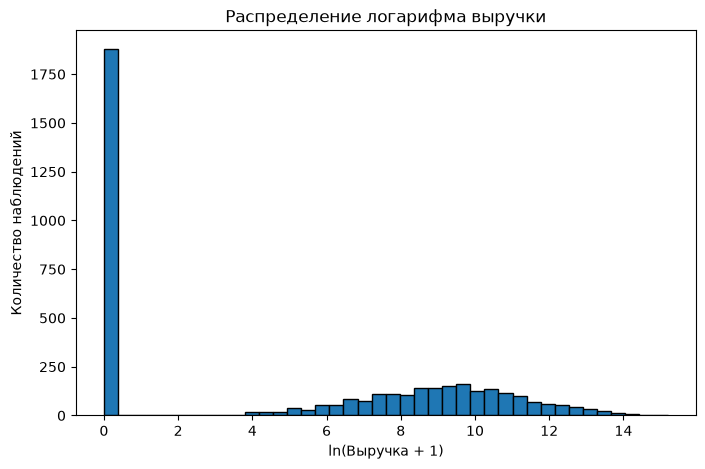

In [25]:
plt.figure(figsize=(8, 5))

plt.hist(df["log_revenue"], bins=40, edgecolor="black")

plt.title("Распределение логарифма выручки")
plt.xlabel("ln(Выручка + 1)")
plt.ylabel("Количество наблюдений")

plt.show()

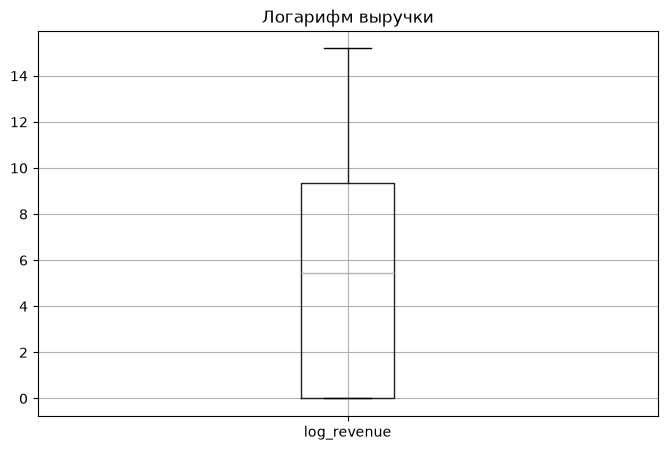

In [26]:
plt.figure(figsize=(8,5))

df.boxplot(column="log_revenue")

plt.title("Логарифм выручки")

plt.show()

### Анализ распределения выручки
Исходное распределение выручки характеризуется высокой правосторонней асимметрией, обусловленной значительными различиями между малыми и крупными строительными организациями. Для уменьшения влияния выбросов было использовано логарифмическое преобразование показателя выручки.

После преобразования распределение приобрело более компактную форму, что позволило визуально оценить структуру выборки. При этом сохраняется выраженный пик в нулевой точке, отражающий высокую долю компаний с нулевой выручкой.

In [27]:
df.groupby("period")[["revenue", "net_profit", "ebit"]].median()

,revenue,net_profit,ebit
period,,,
2021,168.0,0.0,0.0
2022,393.0,0.0,0.0
2023,228.0,0.0,0.0
2024,134.0,0.0,0.0


In [28]:
df.groupby("period")[["revenue", "net_profit", "ebit"]].mean()

,revenue,net_profit,ebit
period,,,
2021,27352.078875,-261.155693,-241.916324
2022,36818.479317,3654.712230,3733.517086
2023,45644.088485,186.254545,311.408485
2024,34995.681592,-1040.918740,-617.258706


Рост средней выручки строительных организаций не сопровождается ростом медианной выручки. Это свидетельствует о том, что увеличение совокупных финансовых показателей отрасли обеспечивается ограниченным числом крупных компаний, тогда как финансовое положение типичной организации практически не улучшается.

### Анализ EBIT

In [29]:
df["ebit"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

count    3.998000e+03
mean     9.213762e+02
std      7.100216e+04
min     -1.610068e+06
1%      -1.870990e+04
5%      -1.462000e+03
25%      0.000000e+00
50%      0.000000e+00
75%      1.227500e+02
95%      3.778750e+03
99%      2.353999e+04
max      3.008874e+06
Name: ebit, dtype: float64

In [30]:
ebit_structure = pd.Series({
    "Положительный": (df["ebit"] > 0).sum(),
    "Нулевой": (df["ebit"] == 0).sum(),
    "Отрицательный": (df["ebit"] < 0).sum()
})

display(ebit_structure)

Положительный    1671
Нулевой          1508
Отрицательный     819
dtype: int64

В исследуемой выборке лишь 41,8% наблюдений имеют положительный операционный финансовый результат (EBIT). При этом 37,7% наблюдений характеризуются нулевым EBIT, а ещё 20,5% — отрицательным. Таким образом, более половины наблюдений (58,2%) не демонстрируют положительного операционного результата.

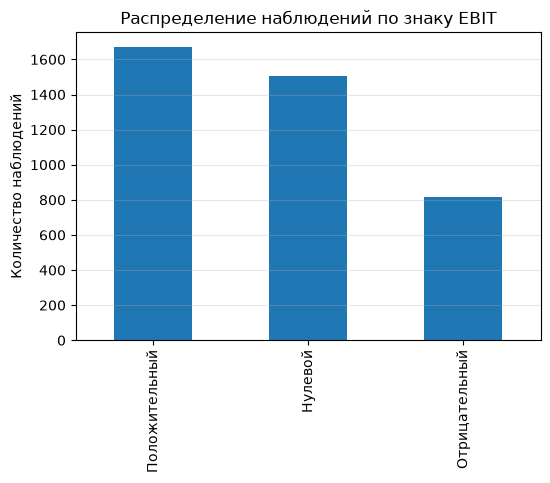

In [31]:
plt.figure(figsize=(6,4))

ebit_structure.plot(kind="bar")

plt.ylabel("Количество наблюдений")
plt.title("Распределение наблюдений по знаку EBIT")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Топ-10 компаний по выручке и EBIT

In [32]:
latest = (
    df.sort_values("period")
      .drop_duplicates("id", keep="last")
)

In [33]:
top_revenue = (
    latest
    .sort_values("revenue", ascending=False)
    [["name", "region", "period", "revenue", "net_profit", "ebit"]]
    .head(10)
)

display(top_revenue)

,name,region,period,revenue,net_profit,ebit
2221,"ООО ""ЧЕРНОМОРЕЦ""",ТЮМЕНСКАЯ,2022,3121485.0,3011437.0,3008874.0
2930,"ООО ""РЕЗИДЕНС""",МОСКВА,2023,1495920.0,45.0,34.0
1997,"ООО ""ЭНЕРГОСТРОЙПРОЕКТ""",САНКТ-ПЕТЕРБУРГ,2024,1462551.0,16001.0,20001.0
2589,"ООО ""СВ КОНСТРАКШНСЕРВИС""",САРАТОВСКАЯ,2021,1293318.0,13099.0,9170.0
2367,"ООО ""ДОРОЖНО-СТРОИТЕЛЬНАЯ КОМПАНИЯ 82""",ЧЕЛЯБИНСКАЯ,2021,1197057.0,1505.0,1886.0
2181,"ООО ""КСС""",МОСКВА,2022,1122553.0,45298.0,35154.0
2811,"ООО ""ГЛОБАЛГРУПП""",МОСКВА,2023,1033348.0,107.0,134.0
506,"ООО ""ЛЕВИТЭК""",МОСКВА,2024,1010990.0,-112077.0,-106402.0
3467,"ООО ""ТРИВАНТИС""",МОСКВА,2023,997645.0,18.0,14.0
1554,"ООО ""ГРАНДСТРОЙ""",МОСКОВСКАЯ,2024,958043.0,-11566.0,-12632.0


In [34]:
top_ebit = (
    latest
    .sort_values("ebit", ascending=False)
    [["name", "region", "period", "revenue", "net_profit", "ebit"]]
    .head(10)
)

display(top_ebit)

,name,region,period,revenue,net_profit,ebit
2221,"ООО ""ЧЕРНОМОРЕЦ""",ТЮМЕНСКАЯ,2022,3121485.0,3011437.0,3008874.0
1329,"ООО ""ЛИВАДИЯ""",МОСКВА,2022,0.0,2590980.0,2619539.0
2420,"ООО ""БРАВО""",ТАТАРСТАН,2024,453340.0,368705.0,359312.0
1608,"ООО ""АЛЬФА-СТРОЙ""",КРАСНОЯРСКИЙ,2024,655426.0,151190.0,183016.0
3773,"ООО ""КАРАВАН""",СВЕРДЛОВСКАЯ,2022,114802.0,94286.0,95932.0
546,"ООО ""МР-ЦЕНТР""",МОСКВА,2021,481056.0,127394.0,88915.0
3155,"ООО ""КЛЕММА""",РОСТОВСКАЯ,2021,533547.0,47151.0,44125.0
578,"ООО ""ЭТАЛОН СТРОЙ""",МУРМАНСКАЯ,2023,378222.0,37056.0,37056.0
3117,"ООО ""СК УЮТНЫЙ ДОМ""",ИВАНОВСКАЯ,2024,53693.0,35814.0,36364.0
2181,"ООО ""КСС""",МОСКВА,2022,1122553.0,45298.0,35154.0


In [35]:
set(top_revenue["name"]) & set(top_ebit["name"])

{'ООО "КСС"', 'ООО "ЧЕРНОМОРЕЦ"'}

Высокая выручка не гарантирует высокий операционный результат (EBIT). Большинство лидеров по объёму выручки не входят в число лидеров по операционной прибыли, что может свидетельствовать о существенных различиях в операционной эффективности, структуре затрат и рентабельности строительных компаний.

In [36]:
latest[["revenue", "ebit"]].corr()

,revenue,ebit
revenue,1.000000,0.379056
ebit,0.379056,1.000000


Корреляция Пирсона 0.37, т.е. умеренная

In [37]:
latest[["revenue", "ebit"]].corr(method="spearman")

,revenue,ebit
revenue,1.000000,0.569996
ebit,0.569996,1.000000


Корреляция Спирмана уже 0.57, т.е. есть определенная выраженная корреляция между выручкой и EBIT. Чем больше компания по выручке, тем выше её EBIT, но эта зависимость далека от линейной.

### 4.3 Динамика

### Изменение средних и медианных показателей по годам

In [39]:
year_dynamics = (
    df.groupby("period")[["revenue", "net_profit", "ebit"]]
      .agg(["mean", "median"])
)

year_dynamics

revenue          net_profit                ebit       
                mean median         mean median         mean median
period                                                             
2021    27352.078875  168.0  -261.155693    0.0  -241.916324    0.0
2022    36818.479317  393.0  3654.712230    0.0  3733.517086    0.0
2023    45644.088485  228.0   186.254545    0.0   311.408485    0.0
2024    34995.681592  134.0 -1040.918740    0.0  -617.258706    0.0

среди наблюдений медианный EBIT и медианная чистая прибыль во все годы равны 0.

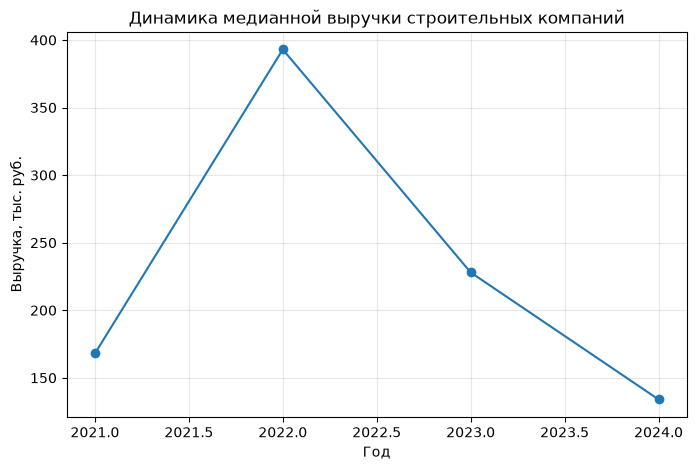

In [40]:
plt.figure(figsize=(8,5))

df.groupby("period")["revenue"].median().plot(
    marker="o"
)

plt.title("Динамика медианной выручки строительных компаний")
plt.xlabel("Год")
plt.ylabel("Выручка, тыс. руб.")

plt.grid(alpha=0.3)

plt.show()

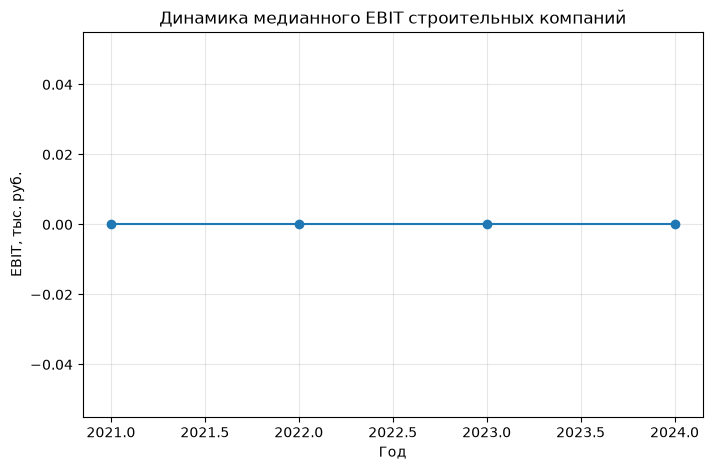

In [41]:
plt.figure(figsize=(8,5))

df.groupby("period")["ebit"].median().plot(
    marker="o"
)

plt.title("Динамика медианного EBIT строительных компаний")
plt.xlabel("Год")
plt.ylabel("EBIT, тыс. руб.")

plt.grid(alpha=0.3)

plt.show()

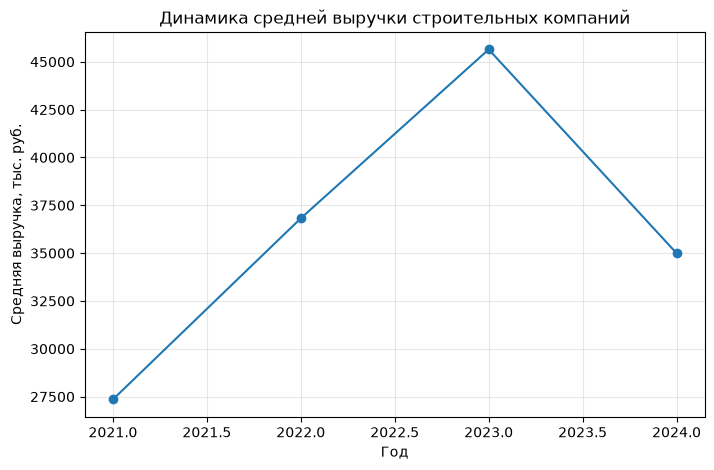

In [42]:
plt.figure(figsize=(8,5))

df.groupby("period")["revenue"].mean().plot(
    marker="o"
)

plt.title("Динамика средней выручки строительных компаний")
plt.xlabel("Год")
plt.ylabel("Средняя выручка, тыс. руб.")

plt.grid(alpha=0.3)

plt.show()

### Вывод
Средняя и медианная выручка демонстрируют различную динамику. Значительное превышение среднего значения над медианой указывает на наличие крупных компаний, которые оказывают существенное влияние на общий показатель отрасли. При этом медианная выручка отражает состояние типичной компании и показывает более умеренную динамику. При динамичном измненении медианной и средней выручки медианный EBIT остается нулевым, что еще рз напоминает о пиковом значении компаний, который по какой-то причине не ведут деятельность или отчетность.

### 4.4 Региональный анализ

### Средняя и медианная выручка по регионам

In [43]:
top_regions = (
    df.groupby("region")["id"]
      .nunique()
      .sort_values(ascending=False)
      .head(15)
      .index
)

In [44]:
region_df = df[df["region"].isin(top_regions)]

In [45]:
region_revenue_mean = (
    region_df.groupby("region")["revenue"]
             .mean()
             .sort_values(ascending=False)
)

display(region_revenue_mean)

region
ТЮМЕНСКАЯ          84200.943396
МОСКВА             65535.132435
САНКТ-ПЕТЕРБУРГ    55776.007576
БАШКОРТОСТАН       50970.855422
ЧЕЛЯБИНСКАЯ        40998.672727
МОСКОВСКАЯ         32192.413223
ТАТАРСТАН          25120.978417
КРАСНОЯРСКИЙ       21191.419355
НОВОСИБИРСКАЯ      16570.584746
НИЖЕГОРОДСКАЯ      15371.541667
САМАРСКАЯ          14697.862069
ПРИМОРСКИЙ         13770.829545
КРАСНОДАРСКИЙ      12329.927273
СВЕРДЛОВСКАЯ       10367.989362
КРЫМ                3428.480000
Name: revenue, dtype: float64

Средняя выручка компаний в Тюменской области больше всех по России среди выбранных наблюдений. Возможно, это означает, что в этом регионе несколько крупных застройщиков, а в Москве из-за количества компаний выручка размывается. 

In [46]:
region_revenue_median = (
    region_df.groupby("region")["revenue"]
             .median()
             .sort_values(ascending=False)
)

display(region_revenue_median)

region
САНКТ-ПЕТЕРБУРГ    5109.5
МОСКВА             1406.0
МОСКОВСКАЯ         1335.5
ТАТАРСТАН           850.0
НИЖЕГОРОДСКАЯ       464.5
НОВОСИБИРСКАЯ       396.5
ТЮМЕНСКАЯ           306.0
БАШКОРТОСТАН        117.0
КРЫМ                  0.0
КРАСНОДАРСКИЙ         0.0
КРАСНОЯРСКИЙ          0.0
САМАРСКАЯ             0.0
ПРИМОРСКИЙ            0.0
СВЕРДЛОВСКАЯ          0.0
ЧЕЛЯБИНСКАЯ           0.0
Name: revenue, dtype: float64

По медиане другая ситуация: хорошо заметно наше наблюдение о большом количестве компаний с медианной выручкой = 0. По России получается, что самые эффективные застройщики в рамках наших наблюдений работают в Петеребурге(если судить по выручке). 

In [47]:
region_summary = (
    region_df.groupby("region")
    .agg(
        companies=("id", "nunique"),
        mean_revenue=("revenue", "mean"),
        median_revenue=("revenue", "median"),
        mean_ebit=("ebit", "mean"),
        median_ebit=("ebit", "median")
    )
    .sort_values("companies", ascending=False)
)

display(region_summary)

,companies,mean_revenue,median_revenue,mean_ebit,median_ebit
region,,,,,
МОСКВА,492,65535.132435,1406.0,2934.748597,1.0
САНКТ-ПЕТЕРБУРГ,127,55776.007576,5109.5,626.780303,14.0
МОСКОВСКАЯ,103,32192.413223,1335.5,-9364.826446,0.0
КРАСНОДАРСКИЙ,75,12329.927273,0.0,125.406061,0.0
БАШКОРТОСТАН,72,50970.855422,117.0,313.632530,0.0
ТАТАРСТАН,66,25120.978417,850.0,3692.287770,0.0
НОВОСИБИРСКАЯ,58,16570.584746,396.5,-2798.050847,0.0
СВЕРДЛОВСКАЯ,49,10367.989362,0.0,1539.627660,0.0
САМАРСКАЯ,42,14697.862069,0.0,-8873.011494,0.0


### Регионы по EBIT

In [48]:
region_ebit_mean = (
    region_df.groupby("region")["ebit"]
             .mean()
             .sort_values(ascending=False)
)

display(region_ebit_mean)

region
ТЮМЕНСКАЯ          62207.811321
ТАТАРСТАН           3692.287770
КРАСНОЯРСКИЙ        3600.274194
МОСКВА              2934.748597
СВЕРДЛОВСКАЯ        1539.627660
НИЖЕГОРОДСКАЯ        966.305556
САНКТ-ПЕТЕРБУРГ      626.780303
ЧЕЛЯБИНСКАЯ          550.072727
БАШКОРТОСТАН         313.632530
КРАСНОДАРСКИЙ        125.406061
ПРИМОРСКИЙ            -0.204545
НОВОСИБИРСКАЯ      -2798.050847
КРЫМ               -3289.200000
САМАРСКАЯ          -8873.011494
МОСКОВСКАЯ         -9364.826446
Name: ebit, dtype: float64

В Тюменской области средний EBIT огромный, скорее всего там есть несколько очень крупных компаний, которые тянут показатели вверх. В остальном всего в 10 регионах средний EBIT больше 0.

In [49]:
region_ebit_median = (
    region_df.groupby("region")["ebit"]
             .median()
             .sort_values(ascending=False)
)

display(region_ebit_median)

region
САНКТ-ПЕТЕРБУРГ    14.0
МОСКВА              1.0
КРАСНОДАРСКИЙ       0.0
КРАСНОЯРСКИЙ        0.0
КРЫМ                0.0
МОСКОВСКАЯ          0.0
БАШКОРТОСТАН        0.0
НИЖЕГОРОДСКАЯ       0.0
НОВОСИБИРСКАЯ       0.0
ПРИМОРСКИЙ          0.0
САМАРСКАЯ           0.0
СВЕРДЛОВСКАЯ        0.0
ТАТАРСТАН           0.0
ТЮМЕНСКАЯ           0.0
ЧЕЛЯБИНСКАЯ         0.0
Name: ebit, dtype: float64

По EBIT опять получили подтверждение того, что по большинству наблюдений EBIT = 0. Так как выборка была случайная, такие данные могут говорить либо о некорректности сведений на сайте ФНС, либо о том, что большая часть компаний действительно не ведет экономической деятельности или отчетности.

## 5. Выводы

В рамках исследования была проведена оценка состояния и динамики строительной отрасли на основе финансовой отчётности организаций с ОКВЭД 41.20. Для анализа была сформирована выборка компаний, по которым были собраны данные о выручке, чистой прибыли и EBIT за несколько лет. Использование данных ФНС позволило рассматривать не только крупные и наиболее успешные организации, но и компании с нулевой выручкой или финансовым результатом, что позволяет получить более полное представление о структуре отрасли.

Анализ показал, что строительная отрасль характеризуется значительной неоднородностью компаний по масштабу и финансовым результатам. Распределение выручки имеет выраженную правостороннюю асимметрию: основная масса компаний располагается в относительно небольшом диапазоне значений, тогда как небольшое количество крупных организаций формирует значительную часть совокупного оборота. Это также проявляется в существенном различии между средними и медианными показателями.

Особенно заметна неоднородность финансовых результатов. В рассматриваемой выборке около 42% наблюдений имеют положительный EBIT, около 38% — нулевой, а около 20% — отрицательный. При этом медианный EBIT в целом равен нулю. Таким образом, типичная компания выборки не демонстрирует значительного операционного финансового результата, тогда как средние показатели существенно зависят от относительно небольшой группы крупных и прибыльных предприятий.

Динамика показателей также не является устойчивой. Средняя выручка увеличивалась с 2021 по 2023 год, после чего в 2024 году снизилась. Средняя чистая прибыль и EBIT демонстрировали ещё большую нестабильность: наиболее высокие значения наблюдались в 2022 году, после чего показатели существенно снизились, а в 2024 году средние значения вновь стали отрицательными. При этом медианные значения прибыли и EBIT оставались около нуля. Это означает, что изменение средних показателей отрасли в значительной степени определяется отдельными крупными компаниями, а не равномерным улучшением или ухудшением положения большинства предприятий.

Корреляционный анализ подтвердил наличие положительной связи между масштабом компании и EBIT. Коэффициент корреляции Пирсона составил около 0,38, а коэффициент Спирмена — около 0,57. Более высокий коэффициент Спирмена указывает на наличие заметной монотонной зависимости, однако характер связи не является линейным. Следовательно, увеличение выручки в целом связано с более высоким EBIT, но само по себе увеличение масштаба компании не гарантирует пропорционального роста операционного результата.

Региональный анализ также выявил существенные различия. Средние показатели выручки и EBIT заметно отличаются между субъектами РФ, однако эти различия необходимо интерпретировать с учётом структуры выборки и влияния крупнейших предприятий. В отдельных регионах высокие средние значения формируются преимущественно за счёт нескольких крупных компаний, тогда как медианные показатели во многих регионах остаются близкими к нулю.

Таким образом, проведённое исследование позволяет охарактеризовать рассматриваемую часть строительной отрасли как неоднородную и характеризующуюся высокой концентрацией финансового результата у относительно небольшого числа компаний. При этом для значительной доли предприятий характерны нулевая выручка, отсутствие существенной прибыли или EBIT, а динамика средних показателей за рассматриваемый период остаётся нестабильной. Одновременно наличие крупных компаний с высокой выручкой и EBIT показывает, что внутри отрасли существуют предприятия, способные демонстрировать существенно более высокие финансовые результаты.

В целом полученные результаты не позволяют однозначно утверждать ни об устойчивом росте, ни о системном ухудшении состояния отрасли. Скорее, строительный сектор представляет собой совокупность компаний, находящихся в существенно различающемся финансовом положении, поэтому оценка его перспектив должна проводиться не только по средним значениям, но и с учётом распределения показателей, структуры компаний, региональных различий и динамики отдельных групп предприятий.

Полученные результаты также показывают ограничения проведённого анализа. Выборка не охватывает все организации отрасли с одинаковой полнотой по каждому году, а финансовые показатели отдельных компаний могут существенно влиять на средние значения. Поэтому дальнейшее исследование перспектив строительной отрасли целесообразно проводить с использованием более устойчивых показателей — медианных значений, темпов роста, рентабельности, распределения компаний по финансовым результатам и, при наличии достаточного объёма данных, методов панельного анализа.